In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

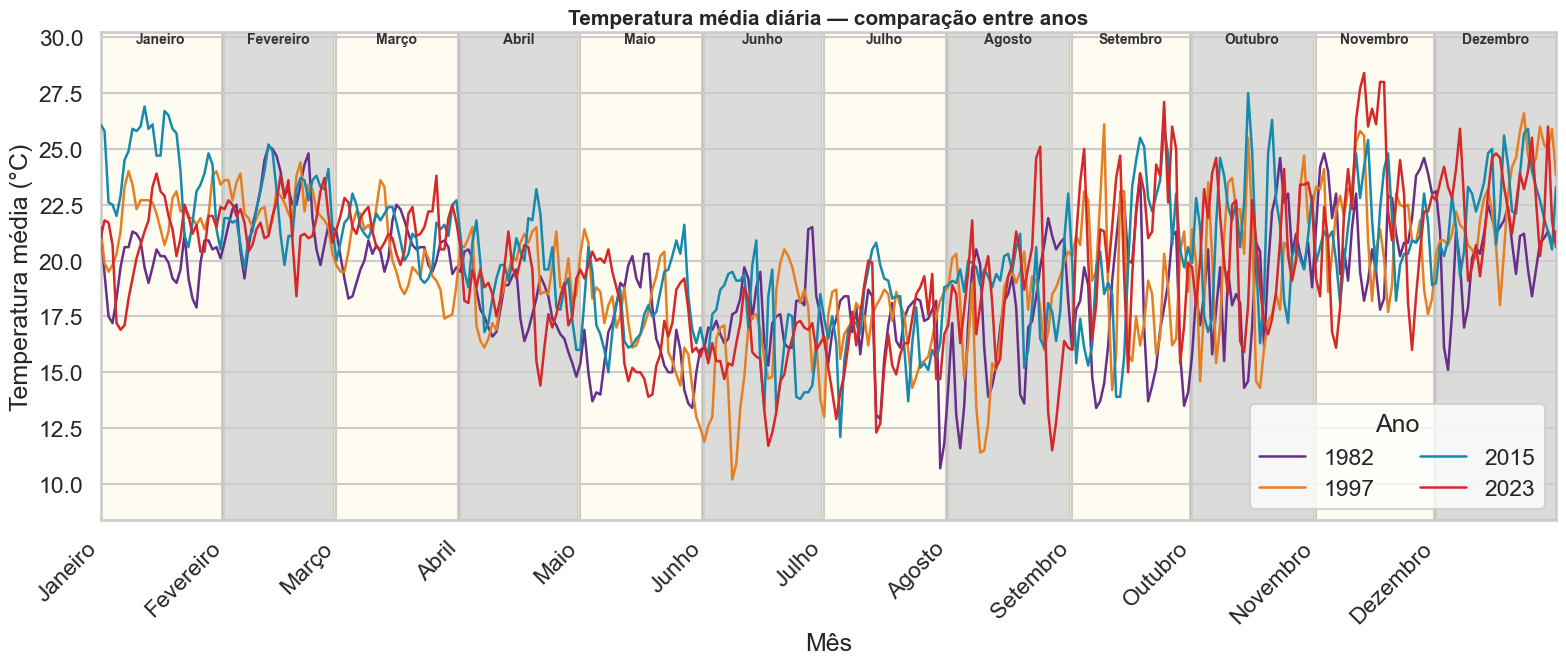

In [6]:
sns.set_theme(style="whitegrid", context="talk")

# ============================================================
# CORES DOS ANOS
# ============================================================
CORES = {
    1982: "#672F8A",
    1997: "#E67E22",
    2015: "#168AAD",
    2023: "#D62828"
}

# ============================================================
# ARQUIVOS
# ============================================================
anos = [1982, 1997, 2015, 2023]

dfs = {}

for ano in anos:

    caminho = f"arquivos/gold/sp_{ano}_0101_1231_gold.csv"

    df = (
        pd.read_csv(
            caminho,
            parse_dates=["Data"]
        )
        .sort_values("Data")
        .reset_index(drop=True)
    )

    # Dia do ano
    df["dia_ano"] = df["Data"].dt.dayofyear

    dfs[ano] = df


# ============================================================
# NOMES DOS MESES
# ============================================================
meses_nome = {
    1: "Janeiro",
    2: "Fevereiro",
    3: "Março",
    4: "Abril",
    5: "Maio",
    6: "Junho",
    7: "Julho",
    8: "Agosto",
    9: "Setembro",
    10: "Outubro",
    11: "Novembro",
    12: "Dezembro"
}


# ============================================================
# CORES DAS FAIXAS DOS MESES
# ============================================================
meses_cores = {
    1: "#FCF3C4",
    2: "#70706D",
    3: "#FCF3C4",
    4: "#70706D",
    5: "#FCF3C4",
    6: "#70706D",
    7: "#FCF3C4",
    8: "#70706D",
    9: "#FCF3C4",
    10: "#70706D",
    11: "#FCF3C4",
    12: "#70706D"
}


# ============================================================
# USAR 1982 PARA DEFINIR AS FAIXAS DOS MESES
# ============================================================
df_base = dfs[1982]

segmentos = (
    df_base.groupby("Mes")["dia_ano"]
    .agg(["min", "max"])
    .reset_index()
)


# ============================================================
# GRÁFICO
# ============================================================
fig, ax = plt.subplots(figsize=(16, 7))


# ============================================================
# FAIXAS DE FUNDO DOS MESES
# ============================================================
for _, row in segmentos.iterrows():

    mes = int(row["Mes"])

    ax.axvspan(
        row["min"] - 0.5,
        row["max"] + 0.5,
        color=meses_cores[mes],
        alpha=0.25,
        zorder=0
    )


# ============================================================
# LINHAS DOS 4 ANOS
# ============================================================
for ano in anos:

    df = dfs[ano]

    ax.plot(
        df["dia_ano"],
        df["Temperatura_media"],
        color=CORES[ano],
        linewidth=1.8,
        label=str(ano),
        zorder=3
    )


# ============================================================
# LIMITES DO EIXO Y
# ============================================================
todos_valores = pd.concat(
    [dfs[ano]["Temperatura_media"] for ano in anos]
)

y_min = todos_valores.min()
y_max = todos_valores.max()

margem = (y_max - y_min) * 0.10

ax.set_ylim(
    y_min - margem,
    y_max + margem
)


# ============================================================
# NOMES DOS MESES NO FUNDO
# ============================================================
y_top = ax.get_ylim()[1]

for _, row in segmentos.iterrows():

    mes = int(row["Mes"])

    centro = (row["min"] + row["max"]) / 2

    ax.text(
        centro,
        y_top,
        meses_nome[mes],
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
        color="#333333"
    )


# ============================================================
# EIXO X
# ============================================================
inicio_mes = (
    df_base.groupby("Mes")["dia_ano"]
    .min()
)

ax.set_xticks(inicio_mes.values)

ax.set_xticklabels(
    [meses_nome[m] for m in inicio_mes.index],
    rotation=45,
    ha="right"
)


# ============================================================
# TÍTULO E EIXOS
# ============================================================
ax.set_title(
    "Temperatura média diária — comparação entre anos",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mês")
ax.set_ylabel("Temperatura média (°C)")


# ============================================================
# LIMITES DO EIXO X
# ============================================================
ax.set_xlim(
    1,
    max(dfs[ano]["dia_ano"].max() for ano in anos)
)


# ============================================================
# LEGENDA
# ============================================================
ax.legend(
    title="Ano",
    loc="lower right",
    ncol=2
)


# ============================================================
# FINALIZAÇÃO
# ============================================================
plt.tight_layout()

plt.savefig(
    "p1_linha_comparacao_1982_1997_2015_2023.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

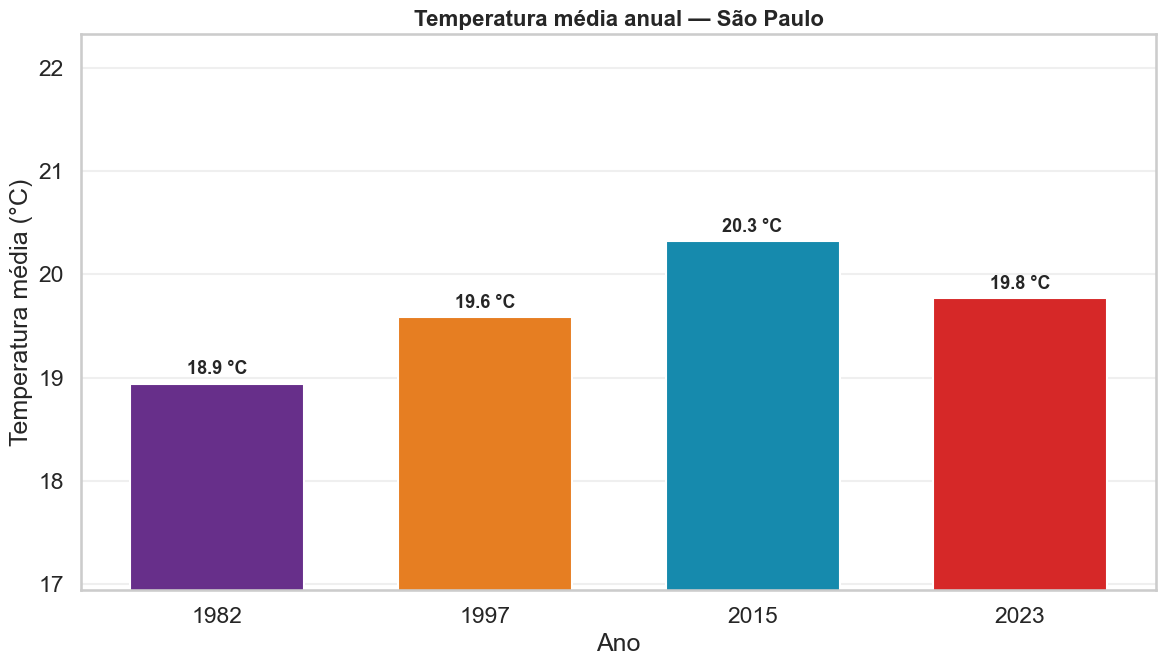

In [7]:
sns.set_theme(style="whitegrid", context="talk")

# ============================================================
# ANOS
# ============================================================
anos = [1982, 1997, 2015, 2023]

# ============================================================
# CORES
# ============================================================
CORES = {
    1982: "#672F8A",
    1997: "#E67E22",
    2015: "#168AAD",
    2023: "#D62828"
}

# ============================================================
# CALCULA A MÉDIA DE CADA ANO
# ============================================================
medias = []

for ano in anos:

    caminho = f"arquivos/gold/sp_{ano}_0101_1231_gold.csv"

    df = pd.read_csv(caminho)

    media = df["Temperatura_media"].mean()

    medias.append({
        "Ano": ano,
        "Temperatura_media": media
    })

df_medias = pd.DataFrame(medias)

# ============================================================
# GRÁFICO
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))

barras = ax.bar(
    df_medias["Ano"].astype(str),
    df_medias["Temperatura_media"],
    color=[CORES[ano] for ano in anos],
    width=0.65
)

# ============================================================
# VALOR EM CIMA DE CADA BARRA
# ============================================================
for barra, valor in zip(
    barras,
    df_medias["Temperatura_media"]
):

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.05,
        f"{valor:.1f} °C",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

# ============================================================
# TÍTULO E EIXOS
# ============================================================
ax.set_title(
    "Temperatura média anual — São Paulo",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Ano")
ax.set_ylabel("Temperatura média (°C)")

# ============================================================
# AJUSTE DO EIXO Y
# ============================================================
y_min = df_medias["Temperatura_media"].min()

ax.set_ylim(
    max(0, y_min - 2),
    df_medias["Temperatura_media"].max() + 2
)

# ============================================================
# GRADE
# ============================================================
ax.grid(
    axis="y",
    alpha=0.3
)

ax.grid(
    axis="x",
    visible=False
)

plt.tight_layout()

# ============================================================
# SALVAR
# ============================================================
plt.savefig(
    "p2_barras_temperatura_media_anual.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

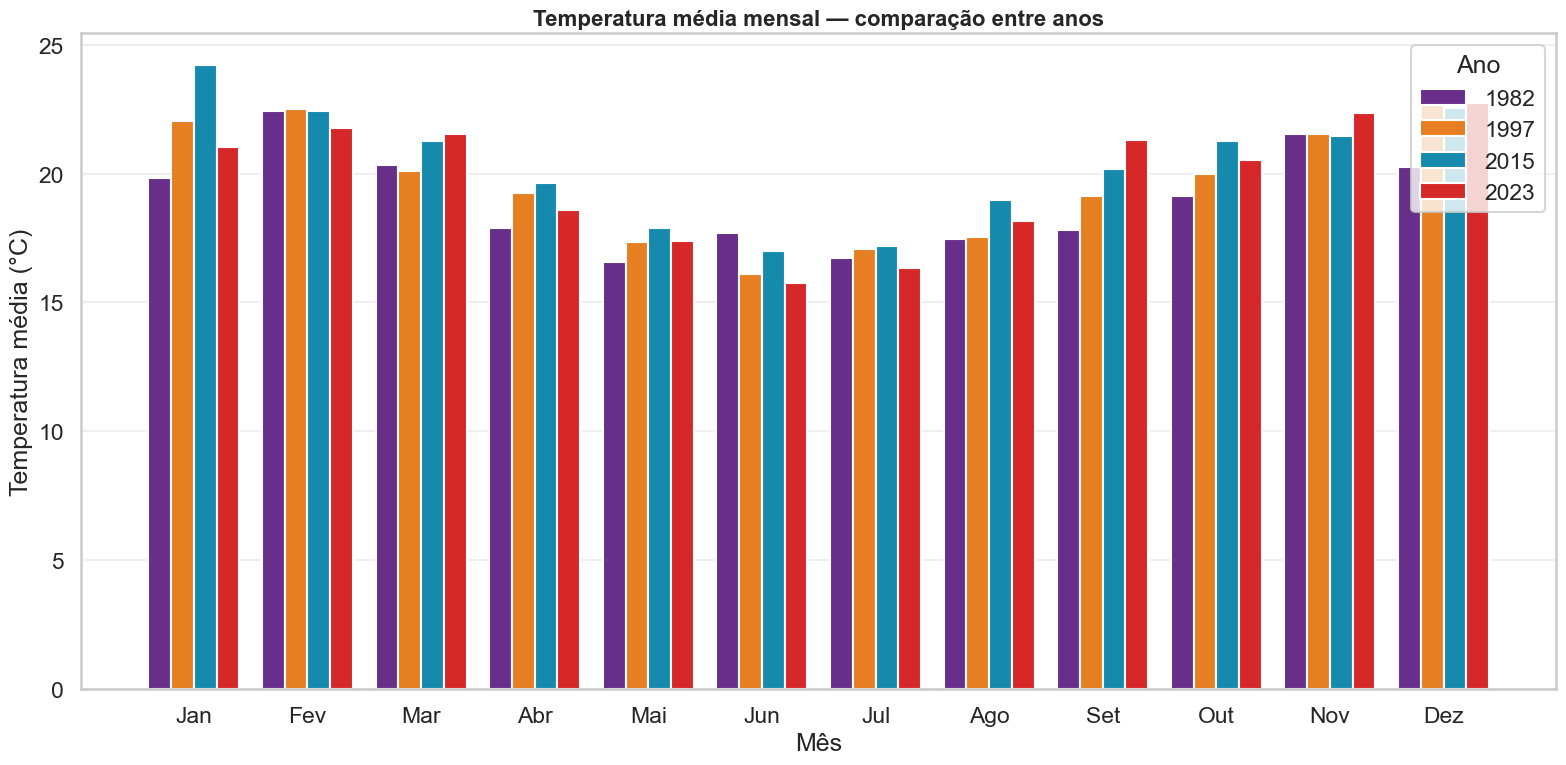

In [8]:
sns.set_theme(style="whitegrid", context="talk")

# ============================================================
# ANOS
# ============================================================
anos = [1982, 1997, 2015, 2023]

# ============================================================
# CORES DOS ANOS
# ============================================================
CORES = {
    1982: "#672F8A",
    1997: "#E67E22",
    2015: "#168AAD",
    2023: "#D62828"
}

# ============================================================
# NOMES DOS MESES
# ============================================================
meses_nome = {
    1: "Jan",
    2: "Fev",
    3: "Mar",
    4: "Abr",
    5: "Mai",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Set",
    10: "Out",
    11: "Nov",
    12: "Dez"
}

# ============================================================
# CALCULAR MÉDIA MENSAL DE CADA ANO
# ============================================================
resultados = []

for ano in anos:

    caminho = f"arquivos/gold/sp_{ano}_0101_1231_gold.csv"

    df = pd.read_csv(caminho)

    # Média da Temperatura_media agrupada pelo mês
    medias_mensais = (
        df.groupby("Mes")["Temperatura_media"]
        .mean()
        .reset_index()
    )

    medias_mensais["Ano"] = ano

    resultados.append(medias_mensais)

# Junta todos os anos
df_medias = pd.concat(
    resultados,
    ignore_index=True
)

# ============================================================
# ORGANIZA OS DADOS
# ============================================================
tabela = df_medias.pivot(
    index="Mes",
    columns="Ano",
    values="Temperatura_media"
)

# Garante a ordem de janeiro a dezembro
tabela = tabela.reindex(range(1, 13))

# ============================================================
# GRÁFICO
# ============================================================
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(12)

largura = 0.20

for i, ano in enumerate(anos):

    valores = tabela[ano].values

    ax.bar(
        x + (i - 1.5) * largura,
        valores,
        width=largura,
        color=CORES[ano],
        label=str(ano)
    )

# ============================================================
# EIXO X
# ============================================================
ax.set_xticks(x)

ax.set_xticklabels(
    [meses_nome[m] for m in range(1, 13)]
)

# ============================================================
# TÍTULO E EIXOS
# ============================================================
ax.set_title(
    "Temperatura média mensal — comparação entre anos",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Mês")
ax.set_ylabel("Temperatura média (°C)")

# ============================================================
# LEGENDA
# ============================================================
ax.legend(
    title="Ano",
    loc="upper right"
)

# ============================================================
# GRADE
# ============================================================
ax.grid(
    axis="y",
    alpha=0.3
)

ax.grid(
    axis="x",
    visible=False
)

# ============================================================
# AJUSTES FINAIS
# ============================================================
plt.tight_layout()

plt.savefig(
    "p3_barras_temperatura_media_mensal.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

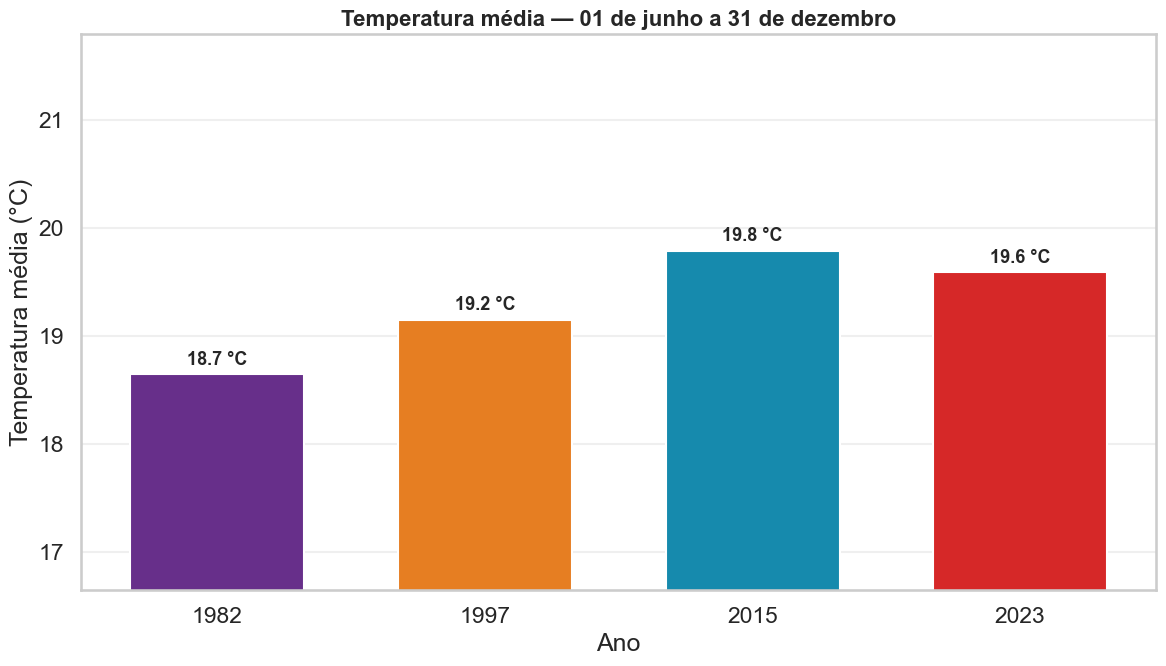

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# ============================================================
# ANOS
# ============================================================
anos = [1982, 1997, 2015, 2023]

# ============================================================
# CORES
# ============================================================
CORES = {
    1982: "#672F8A",
    1997: "#E67E22",
    2015: "#168AAD",
    2023: "#D62828"
}

# ============================================================
# CALCULA A MÉDIA DE 01/JUN A 31/DEZ
# ============================================================
medias = []

for ano in anos:

    caminho = f"arquivos/gold/sp_{ano}_0101_1231_gold.csv"

    df = pd.read_csv(
        caminho,
        parse_dates=["Data"]
    )

    # Filtra somente de 01 de junho até 31 de dezembro
    periodo = df[
        (df["Data"].dt.month >= 6)
    ].copy()

    # Média de todas as Temperatura_media do período
    media = periodo["Temperatura_media"].mean()

    medias.append({
        "Ano": ano,
        "Temperatura_media": media
    })

df_medias = pd.DataFrame(medias)

# ============================================================
# GRÁFICO
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))

barras = ax.bar(
    df_medias["Ano"].astype(str),
    df_medias["Temperatura_media"],
    color=[CORES[ano] for ano in anos],
    width=0.65
)

# ============================================================
# VALOR EM CIMA DE CADA BARRA
# ============================================================
for barra, valor in zip(
    barras,
    df_medias["Temperatura_media"]
):

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.05,
        f"{valor:.1f} °C",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

# ============================================================
# TÍTULO E EIXOS
# ============================================================
ax.set_title(
    "Temperatura média — 01 de junho a 31 de dezembro",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Ano")
ax.set_ylabel("Temperatura média (°C)")

# ============================================================
# AJUSTE DO EIXO Y
# ============================================================
y_min = df_medias["Temperatura_media"].min()
y_max = df_medias["Temperatura_media"].max()

ax.set_ylim(
    max(0, y_min - 2),
    y_max + 2
)

# ============================================================
# GRADE
# ============================================================
ax.grid(
    axis="y",
    alpha=0.3
)

ax.grid(
    axis="x",
    visible=False
)

plt.tight_layout()

# ============================================================
# SALVAR
# ============================================================
plt.savefig(
    "p2_barras_temperatura_media_jun_dez.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

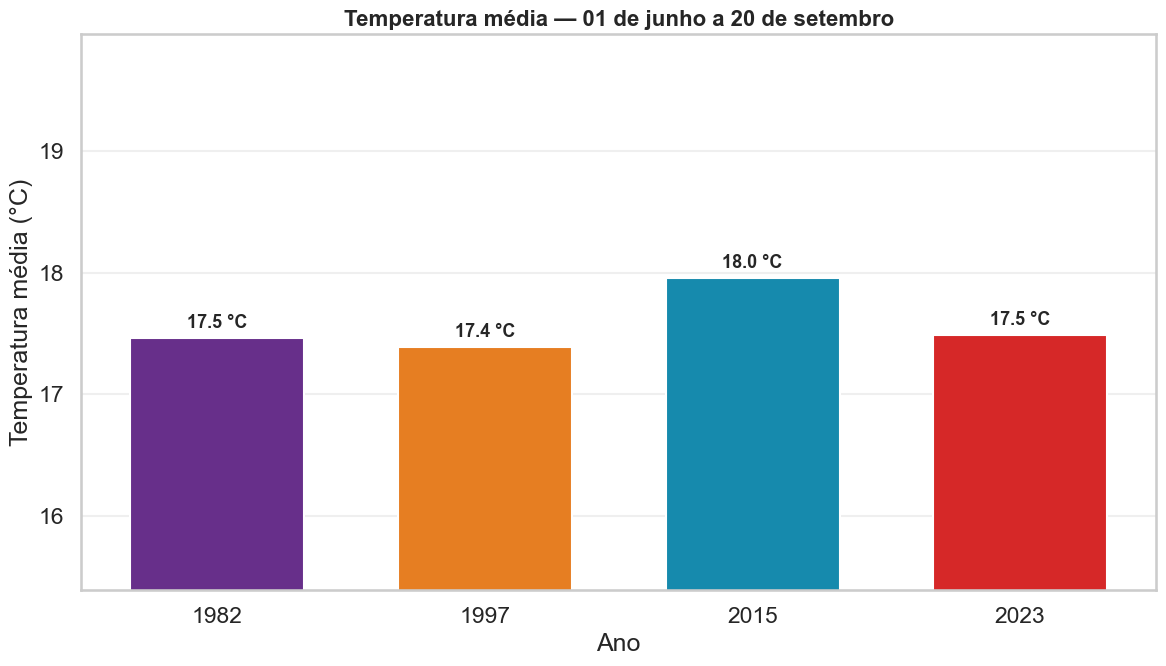

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# ============================================================
# ANOS
# ============================================================
anos = [1982, 1997, 2015, 2023]

# ============================================================
# CORES
# ============================================================
CORES = {
    1982: "#672F8A",
    1997: "#E67E22",
    2015: "#168AAD",
    2023: "#D62828"
}

# ============================================================
# CALCULA A MÉDIA DE 01/JUN A 20/SET
# ============================================================
medias = []

for ano in anos:

    caminho = f"arquivos/gold/sp_{ano}_0101_1231_gold.csv"

    df = pd.read_csv(
        caminho,
        parse_dates=["Data"]
    )

    # --------------------------------------------------------
    # Define o período exato
    # --------------------------------------------------------
    inicio = pd.Timestamp(
        year=ano,
        month=6,
        day=1
    )

    fim = pd.Timestamp(
        year=ano,
        month=9,
        day=20
    )

    periodo = df[
        (df["Data"] >= inicio) &
        (df["Data"] <= fim)
    ].copy()

    # --------------------------------------------------------
    # Média da temperatura no período
    # --------------------------------------------------------
    media = periodo["Temperatura_media"].mean()

    medias.append({
        "Ano": ano,
        "Temperatura_media": media
    })

df_medias = pd.DataFrame(medias)

# ============================================================
# GRÁFICO
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))

barras = ax.bar(
    df_medias["Ano"].astype(str),
    df_medias["Temperatura_media"],
    color=[CORES[ano] for ano in anos],
    width=0.65
)

# ============================================================
# VALOR EM CIMA DE CADA BARRA
# ============================================================
for barra, valor in zip(
    barras,
    df_medias["Temperatura_media"]
):

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.05,
        f"{valor:.1f} °C",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

# ============================================================
# TÍTULO E EIXOS
# ============================================================
ax.set_title(
    "Temperatura média — 01 de junho a 20 de setembro",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Ano")
ax.set_ylabel("Temperatura média (°C)")

# ============================================================
# AJUSTE DO EIXO Y
# ============================================================
y_min = df_medias["Temperatura_media"].min()
y_max = df_medias["Temperatura_media"].max()

ax.set_ylim(
    max(0, y_min - 2),
    y_max + 2
)

# ============================================================
# GRADE
# ============================================================
ax.grid(
    axis="y",
    alpha=0.3
)

ax.grid(
    axis="x",
    visible=False
)

plt.tight_layout()

# ============================================================
# SALVAR
# ============================================================
plt.savefig(
    "p2_barras_temperatura_media_jun_01_set_20.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

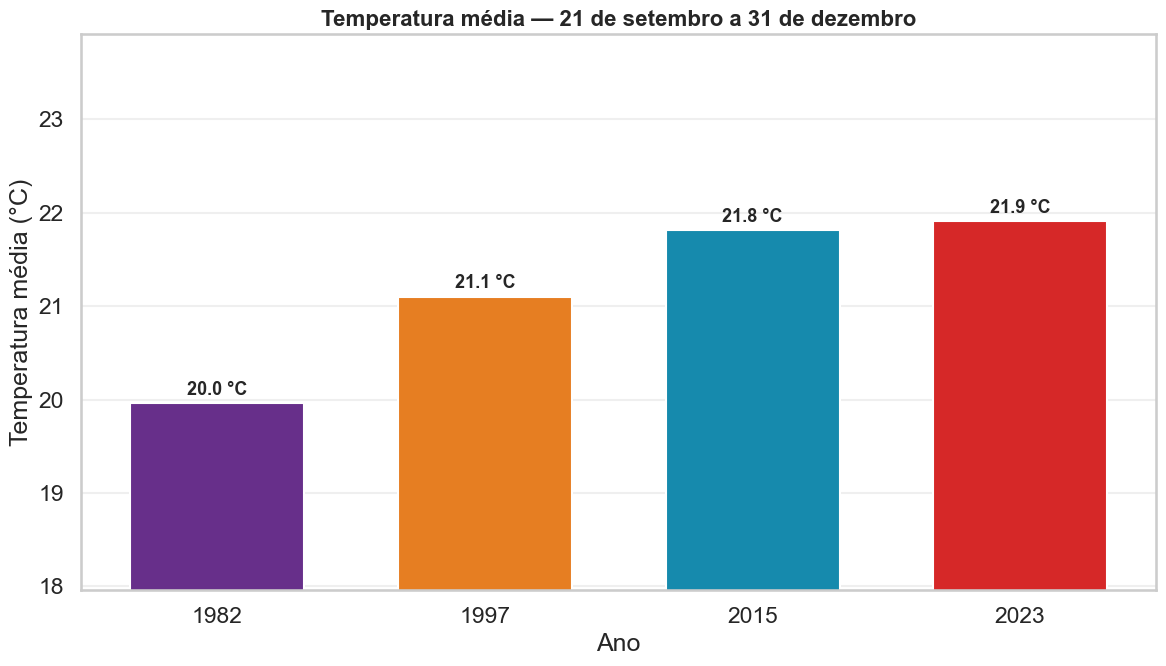

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# ============================================================
# ANOS
# ============================================================
anos = [1982, 1997, 2015, 2023]

# ============================================================
# CORES
# ============================================================
CORES = {
    1982: "#672F8A",
    1997: "#E67E22",
    2015: "#168AAD",
    2023: "#D62828"
}

# ============================================================
# CALCULA A MÉDIA DE 01/JUN A 20/SET
# ============================================================
medias = []

for ano in anos:

    caminho = f"arquivos/gold/sp_{ano}_0101_1231_gold.csv"

    df = pd.read_csv(
        caminho,
        parse_dates=["Data"]
    )

    # --------------------------------------------------------
    # Define o período exato
    # --------------------------------------------------------
    inicio = pd.Timestamp(
        year=ano,
        month=9,
        day=21
    )

    fim = pd.Timestamp(
        year=ano,
        month=12,
        day=31
    )

    periodo = df[
        (df["Data"] >= inicio) &
        (df["Data"] <= fim)
    ].copy()

    # --------------------------------------------------------
    # Média da temperatura no período
    # --------------------------------------------------------
    media = periodo["Temperatura_media"].mean()

    medias.append({
        "Ano": ano,
        "Temperatura_media": media
    })

df_medias = pd.DataFrame(medias)

# ============================================================
# GRÁFICO
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))

barras = ax.bar(
    df_medias["Ano"].astype(str),
    df_medias["Temperatura_media"],
    color=[CORES[ano] for ano in anos],
    width=0.65
)

# ============================================================
# VALOR EM CIMA DE CADA BARRA
# ============================================================
for barra, valor in zip(
    barras,
    df_medias["Temperatura_media"]
):

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.05,
        f"{valor:.1f} °C",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold"
    )

# ============================================================
# TÍTULO E EIXOS
# ============================================================
ax.set_title(
    "Temperatura média — 21 de setembro a 31 de dezembro",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Ano")
ax.set_ylabel("Temperatura média (°C)")

# ============================================================
# AJUSTE DO EIXO Y
# ============================================================
y_min = df_medias["Temperatura_media"].min()
y_max = df_medias["Temperatura_media"].max()

ax.set_ylim(
    max(0, y_min - 2),
    y_max + 2
)

# ============================================================
# GRADE
# ============================================================
ax.grid(
    axis="y",
    alpha=0.3
)

ax.grid(
    axis="x",
    visible=False
)

plt.tight_layout()

# ============================================================
# SALVAR
# ============================================================
plt.savefig(
    "p2_barras_temperatura_media_jun_01_set_20.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

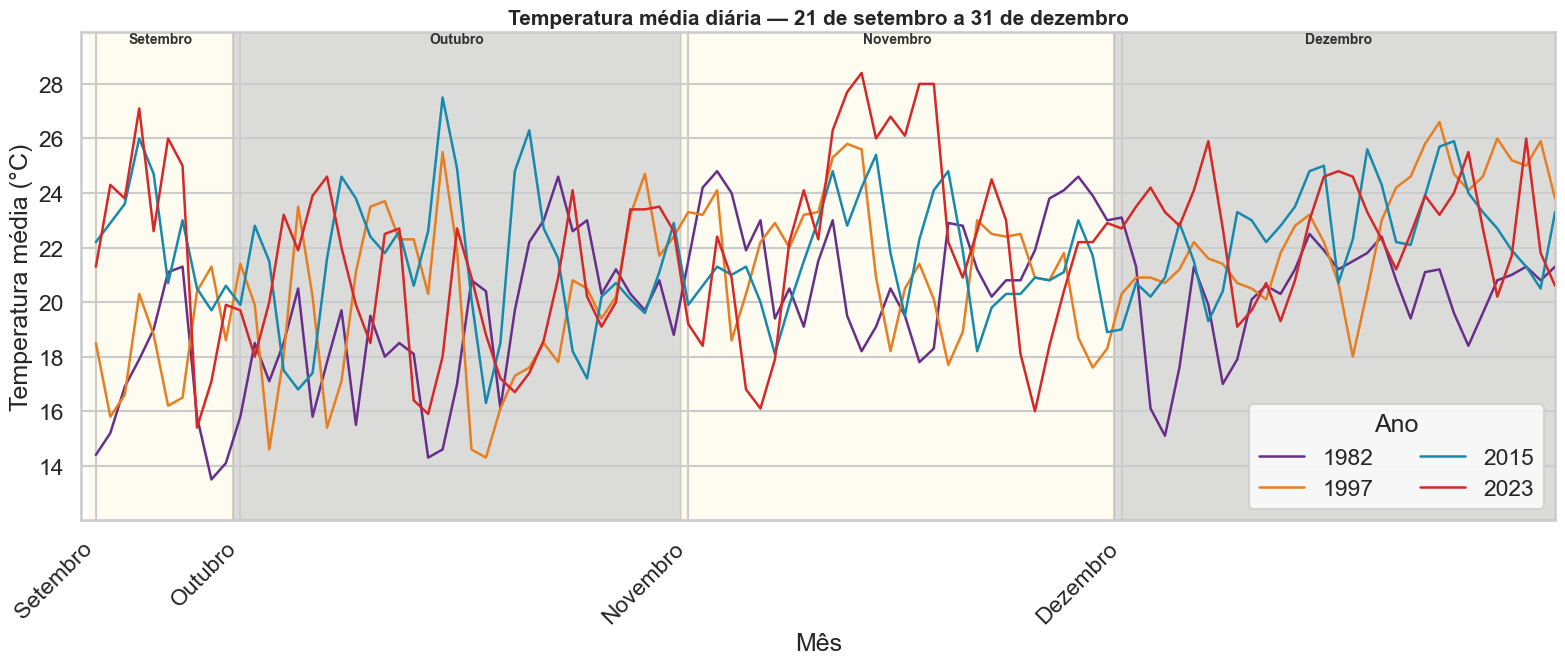

In [13]:
sns.set_theme(style="whitegrid", context="talk")

# ============================================================
# CORES DOS ANOS
# ============================================================
CORES = {
    1982: "#672F8A",
    1997: "#E67E22",
    2015: "#168AAD",
    2023: "#D62828"
}

# ============================================================
# ARQUIVOS
# ============================================================
anos = [1982, 1997, 2015, 2023]

dfs = {}

for ano in anos:

    caminho = f"arquivos/gold/sp_{ano}_0101_1231_gold.csv"

    df = (
        pd.read_csv(
            caminho,
            parse_dates=["Data"]
        )
        .sort_values("Data")
        .reset_index(drop=True)
    )

    # ========================================================
    # FILTRA DE 21 DE SETEMBRO ATÉ 31 DE DEZEMBRO
    # ========================================================
    inicio = pd.Timestamp(
        year=ano,
        month=9,
        day=21
    )

    fim = pd.Timestamp(
        year=ano,
        month=12,
        day=31
    )

    df = df[
        (df["Data"] >= inicio) &
        (df["Data"] <= fim)
    ].copy()

    # ========================================================
    # DIA DO ANO
    # ========================================================
    df["dia_ano"] = df["Data"].dt.dayofyear

    dfs[ano] = df


# ============================================================
# NOMES DOS MESES
# ============================================================
meses_nome = {
    9: "Setembro",
    10: "Outubro",
    11: "Novembro",
    12: "Dezembro"
}


# ============================================================
# CORES DAS FAIXAS DOS MESES
# ============================================================
meses_cores = {
    9: "#FCF3C4",
    10: "#70706D",
    11: "#FCF3C4",
    12: "#70706D"
}


# ============================================================
# USAR 1982 PARA DEFINIR AS FAIXAS DOS MESES
# ============================================================
df_base = dfs[1982]

segmentos = (
    df_base.groupby("Mes")["dia_ano"]
    .agg(["min", "max"])
    .reset_index()
)


# ============================================================
# GRÁFICO
# ============================================================
fig, ax = plt.subplots(figsize=(16, 7))


# ============================================================
# FAIXAS DE FUNDO DOS MESES
# ============================================================
for _, row in segmentos.iterrows():

    mes = int(row["Mes"])

    ax.axvspan(
        row["min"] - 0.5,
        row["max"] + 0.5,
        color=meses_cores[mes],
        alpha=0.25,
        zorder=0
    )


# ============================================================
# LINHAS DOS 4 ANOS
# ============================================================
for ano in anos:

    df = dfs[ano]

    ax.plot(
        df["dia_ano"],
        df["Temperatura_media"],
        color=CORES[ano],
        linewidth=1.8,
        label=str(ano),
        zorder=3
    )


# ============================================================
# LIMITES DO EIXO Y
# ============================================================
todos_valores = pd.concat(
    [dfs[ano]["Temperatura_media"] for ano in anos]
)

y_min = todos_valores.min()
y_max = todos_valores.max()

margem = (y_max - y_min) * 0.10

ax.set_ylim(
    y_min - margem,
    y_max + margem
)


# ============================================================
# NOMES DOS MESES NO FUNDO
# ============================================================
y_top = ax.get_ylim()[1]

for _, row in segmentos.iterrows():

    mes = int(row["Mes"])

    centro = (row["min"] + row["max"]) / 2

    ax.text(
        centro,
        y_top,
        meses_nome[mes],
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
        color="#333333"
    )


# ============================================================
# EIXO X
# ============================================================
inicio_mes = (
    df_base.groupby("Mes")["dia_ano"]
    .min()
)

ax.set_xticks(inicio_mes.values)

ax.set_xticklabels(
    [meses_nome[m] for m in inicio_mes.index],
    rotation=45,
    ha="right"
)


# ============================================================
# TÍTULO E EIXOS
# ============================================================
ax.set_title(
    "Temperatura média diária — 21 de setembro a 31 de dezembro",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mês")
ax.set_ylabel("Temperatura média (°C)")


# ============================================================
# LIMITES DO EIXO X
# ============================================================
ax.set_xlim(
    df_base["dia_ano"].min() - 1,
    max(dfs[ano]["dia_ano"].max() for ano in anos)
)


# ============================================================
# LEGENDA
# ============================================================
ax.legend(
    title="Ano",
    loc="lower right",
    ncol=2
)


# ============================================================
# FINALIZAÇÃO
# ============================================================
plt.tight_layout()

plt.savefig(
    "p1_linha_comparacao_21_set_31_dez_1982_1997_2015_2023.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

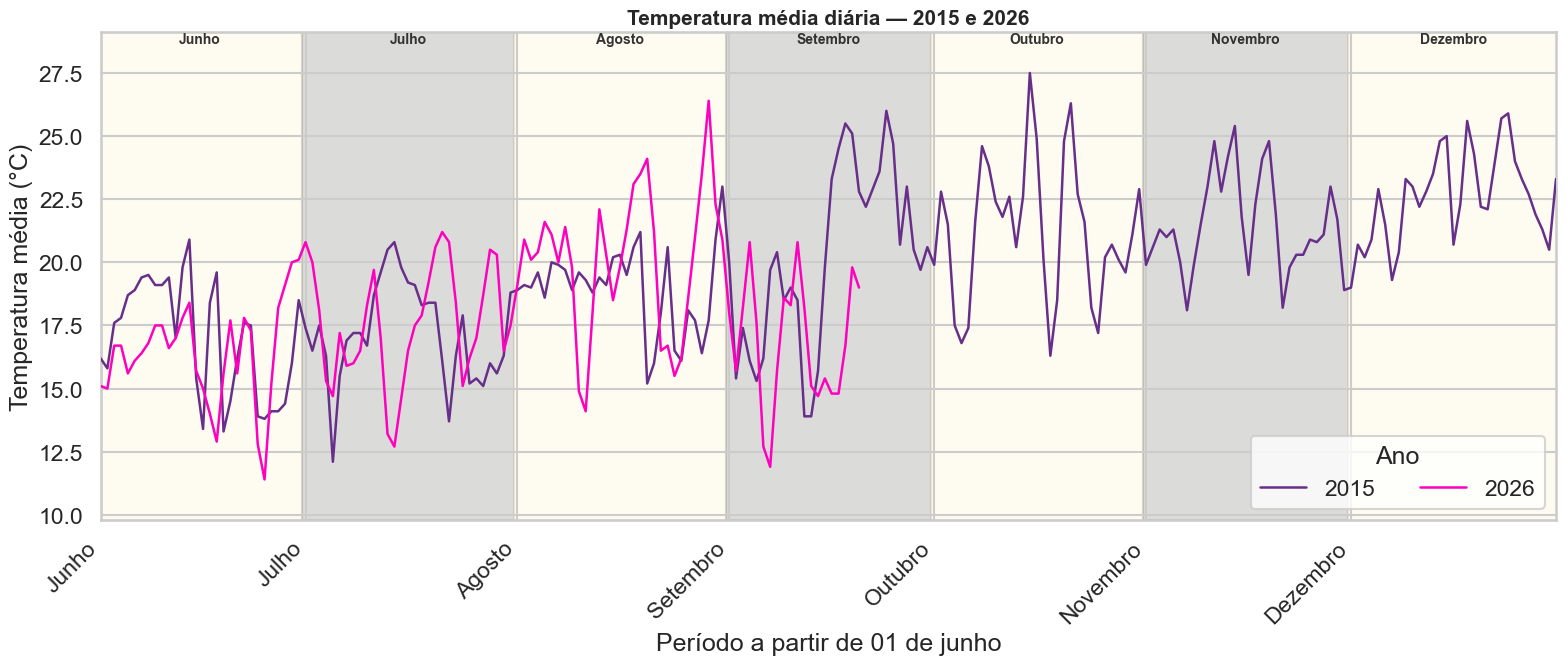

In [3]:
sns.set_theme(style="whitegrid", context="talk")

# ============================================================
# CORES DOS ANOS
# ============================================================
CORES = {
    2015: "#672F8A",
    2026: "#ff00be"
}

# ============================================================
# ARQUIVOS
# ============================================================
arquivos = {
    2015: "arquivos/gold/sp_2015_0101_1231_gold.csv",
    2026: "arquivos/gold/sp_2026_0601_0920_gold.csv"
}

dfs = {}

# ============================================================
# LEITURA DOS ARQUIVOS
# ============================================================
for ano in arquivos:

    df = (
        pd.read_csv(
            arquivos[ano],
            parse_dates=["Data"]
        )
        .sort_values("Data")
        .reset_index(drop=True)
    )

    # ========================================================
    # FILTRA O PERÍODO
    # ========================================================
    if ano == 2015:

        inicio = pd.Timestamp(
            year=2015,
            month=6,
            day=1
        )

        fim = pd.Timestamp(
            year=2015,
            month=12,
            day=31
        )

    else:

        inicio = pd.Timestamp(
            year=2026,
            month=6,
            day=1
        )

        fim = pd.Timestamp(
            year=2026,
            month=9,
            day=20
        )

    df = df[
        (df["Data"] >= inicio) &
        (df["Data"] <= fim)
    ].copy()

    # ========================================================
    # DIA DO PERÍODO
    # ========================================================
    df["dia_periodo"] = (
        df["Data"] - inicio
    ).dt.days + 1

    dfs[ano] = df


# ============================================================
# NOMES DOS MESES
# ============================================================
meses_nome = {
    6: "Junho",
    7: "Julho",
    8: "Agosto",
    9: "Setembro",
    10: "Outubro",
    11: "Novembro",
    12: "Dezembro"
}


# ============================================================
# CORES DAS FAIXAS DOS MESES
# ============================================================
meses_cores = {
    6: "#FCF3C4",
    7: "#70706D",
    8: "#FCF3C4",
    9: "#70706D",
    10: "#FCF3C4",
    11: "#70706D",
    12: "#FCF3C4"
}


# ============================================================
# USAR 2015 PARA DEFINIR AS FAIXAS DOS MESES
# ============================================================
df_base = dfs[2015].copy()

df_base["mes"] = df_base["Data"].dt.month

segmentos = (
    df_base.groupby("mes")["dia_periodo"]
    .agg(["min", "max"])
    .reset_index()
)


# ============================================================
# GRÁFICO
# ============================================================
fig, ax = plt.subplots(figsize=(16, 7))


# ============================================================
# FAIXAS DE FUNDO DOS MESES
# ============================================================
for _, row in segmentos.iterrows():

    mes = int(row["mes"])

    ax.axvspan(
        row["min"] - 0.5,
        row["max"] + 0.5,
        color=meses_cores[mes],
        alpha=0.25,
        zorder=0
    )


# ============================================================
# LINHAS DOS ANOS
# ============================================================
for ano in arquivos:

    df = dfs[ano]

    ax.plot(
        df["dia_periodo"],
        df["Temperatura_media"],
        color=CORES[ano],
        linewidth=1.8,
        label=str(ano),
        zorder=3
    )


# ============================================================
# LIMITES DO EIXO Y
# ============================================================
todos_valores = pd.concat(
    [
        dfs[ano]["Temperatura_media"]
        for ano in arquivos
    ]
)

y_min = todos_valores.min()
y_max = todos_valores.max()

margem = (y_max - y_min) * 0.10

ax.set_ylim(
    y_min - margem,
    y_max + margem
)


# ============================================================
# NOMES DOS MESES
# ============================================================
y_top = ax.get_ylim()[1]

for _, row in segmentos.iterrows():

    mes = int(row["mes"])

    centro = (
        row["min"] + row["max"]
    ) / 2

    ax.text(
        centro,
        y_top,
        meses_nome[mes],
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
        color="#333333"
    )


# ============================================================
# EIXO X
# ============================================================
inicio_mes = (
    df_base.groupby("mes")["dia_periodo"]
    .min()
)

ax.set_xticks(
    inicio_mes.values
)

ax.set_xticklabels(
    [
        meses_nome[m]
        for m in inicio_mes.index
    ],
    rotation=45,
    ha="right"
)


# ============================================================
# TÍTULO E EIXOS
# ============================================================
ax.set_title(
    "Temperatura média diária — 2015 e 2026",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Período a partir de 01 de junho")
ax.set_ylabel("Temperatura média (°C)")


# ============================================================
# LIMITE DO EIXO X
# ============================================================
ax.set_xlim(
    1,
    max(
        dfs[ano]["dia_periodo"].max()
        for ano in arquivos
    )
)


# ============================================================
# LEGENDA
# ============================================================
ax.legend(
    title="Ano",
    loc="lower right",
    ncol=2
)


# ============================================================
# FINALIZAÇÃO
# ============================================================
plt.tight_layout()

plt.savefig(
    "p1_linha_comparacao_2015_2026_jun_dez.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()